In [62]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import math 

%matplotlib inline


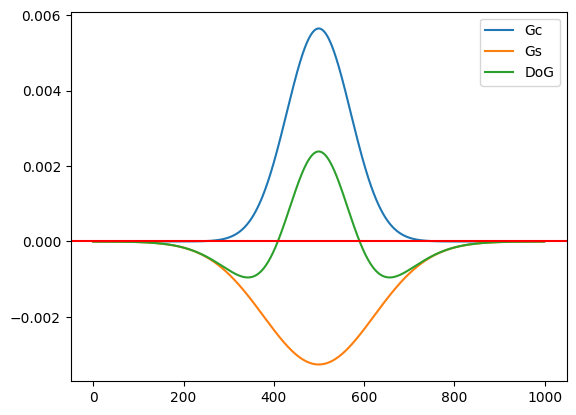

In [63]:
space = np.linspace(-100,100,1000)
sigma = 200*np.ones(len(space))
sigma2 = 600*np.ones(len(space))

gc = 1/(2*math.pi*sigma)*(math.e*np.ones(len(space)))**(-(space*space)/(2*sigma))

gc = gc/np.sum(gc)

gs = 1/(2*math.pi*sigma2)*(math.e*np.ones(len(space)))**(-(space*space)/(2*sigma2))

gs = gs/np.sum(gs)

gcp, = plt.plot(gc, label="Gc")
gsp, = plt.plot(-gs, label="Gs")
dogp, = plt.plot(gc-gs, label="DoG")
plt.axhline(0, c="red")
plt.legend(handles=[gcp,gsp,dogp])
plt.show()


Text(0.5, 1.0, 'Difference of 2D Gaussians (DoG)')

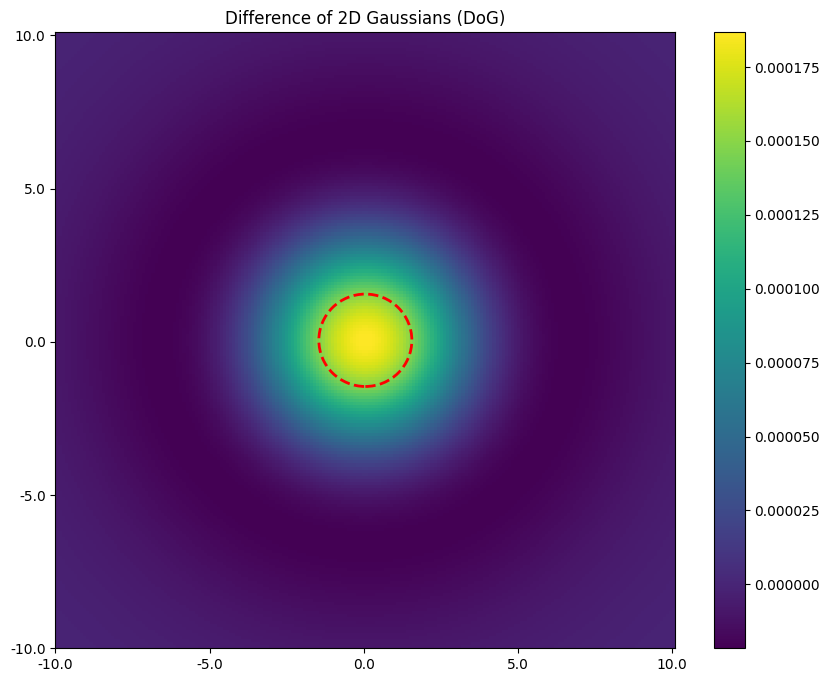

In [195]:
# Show a difference of 2d gaussians
x = np.linspace(-20, 20, 200)
y = np.linspace(-20, 20, 200)
X, Y = np.meshgrid(x, y)

def dog_2d(X, Y, sigmac, sigmas):
    Gc = (1 / (2 * np.pi * sigmac**2)) * np.exp(-(X**2 + Y**2) / (2 * sigmac**2))
    Gc = Gc/np.sum(Gc)
    Gs = (1 / (2 * np.pi * sigmas**2)) * np.exp(-(X**2 + Y**2) / (2 * sigmas**2))
    Gs = Gs/np.sum(Gs)
    return Gc - Gs

Z = dog_2d(X, Y, sigmac = 5, sigmas = 10)

fig, ax = plt.subplots(figsize=(10, 8))
ax.pcolormesh(Z, cmap='viridis')
ax.set_xticks(np.linspace(0, len(x)-1, 5))
ax.set_yticks(np.linspace(0, len(y)-1, 5))
ax.set_xticklabels(np.linspace(-10, 10, 5))
ax.set_yticklabels(np.linspace(-10, 10, 5))
fig.colorbar(ax.pcolormesh(Z, cmap='viridis'))
# plot a circle where the difference of gaussians crosses zero
circle = plt.Circle((len(x)//2, len(y)//2), radius=15, color='red', fill=False, linestyle='--', linewidth=2)
ax.add_artist(circle)
ax.set_title('Difference of 2D Gaussians (DoG)')

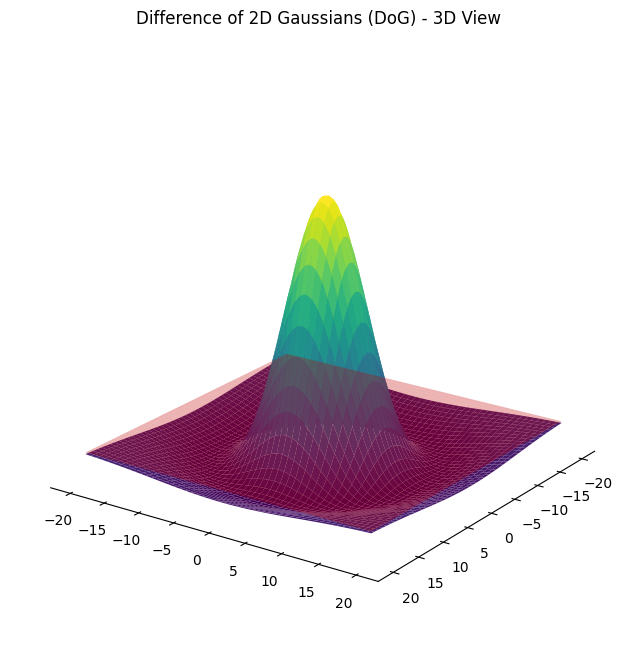

In [212]:
# plot the difference of 2d gaussians in 3d
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_title('Difference of 2D Gaussians (DoG) - 3D View')
# set view angle
ax.view_init(elev=20, azim=35)
# plot a transparent plane at z=0
ax.plot_surface(X, Y, np.zeros_like(Z), alpha=0.3, color='red')

# turn off grid
ax.grid(False)


# Hide the background panes (the 'walls' of the 3D plot)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# # Hide the axis lines themselves (the spine/border)
# ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
# ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))

ax.set_zticks([])
ax.set_zticklabels([])

plt.show()

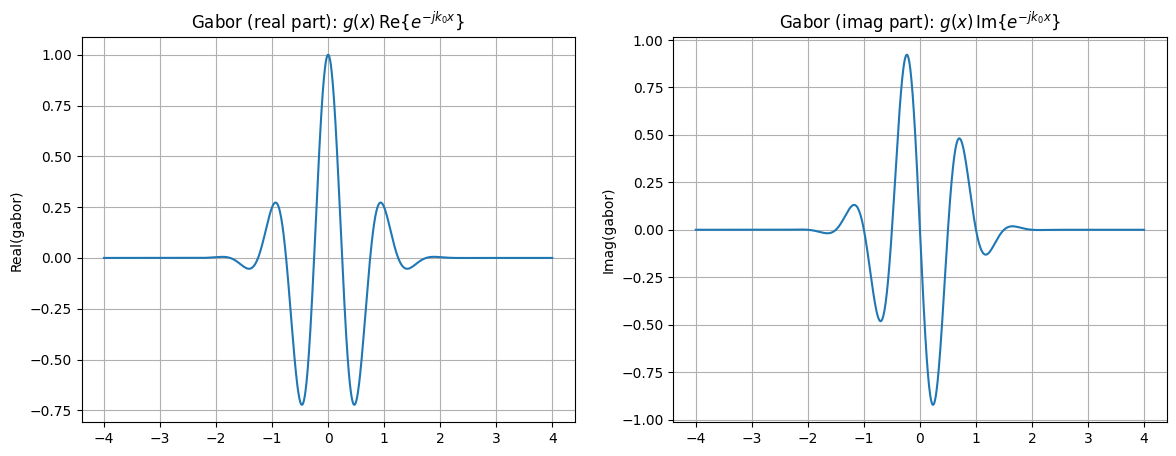

In [214]:
# Parameters (adjust as needed)
k0 = 2 * np.pi * 1.0    # angular frequency (rad/unit). Here 1 cycle per unit -> 2π
sigma = 0.6           # Gaussian standard deviation
x0 = 0.0                # Gaussian center
x_min, x_max = -4.0, 4.0
n_points = 1200

# Domain and functions
x = np.linspace(x_min, x_max, n_points)
gauss = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))
complex_sinusoid = np.exp(-1j * k0 * x)
gabor = gauss * complex_sinusoid

fig, ax = plt.subplots(1,2, figsize=(14, 5))
# Plot: Real part
ax[0].plot(x, gabor.real)
ax[0].set_title("Gabor (real part): $g(x)\\,\\mathrm{Re}\\{e^{-j k_0 x}\\}$")
ax[0].set_ylabel("Real(gabor)")
ax[0].grid(True)

# Plot: Imaginary part
ax[1].plot(x, gabor.imag)
ax[1].set_title("Gabor (imag part): $g(x)\\,\\mathrm{Im}\\{e^{-j k_0 x}\\}$")
ax[1].set_ylabel("Imag(gabor)")
ax[1].grid(True)

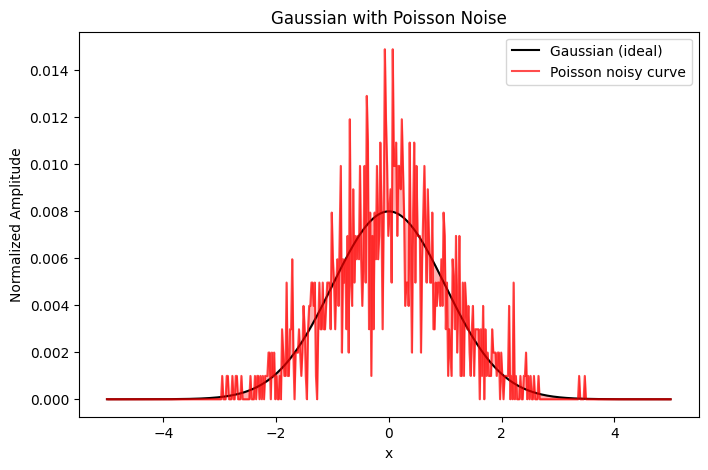

In [217]:
# Parameters for the Gaussian
mu = 0.0      # mean
sigma = 1.0   # standard deviation
x = np.linspace(-5, 5, 500)
gaussian = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
gaussian /= gaussian.sum()  # normalize

# Simulate Poisson noise
N_samples = 1000
noisy_counts = np.random.poisson(lam=gaussian * N_samples)

# Convert noisy counts back to normalized "density"
noisy_curve = noisy_counts / noisy_counts.sum()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, gaussian, 'k-', label="Gaussian (ideal)")
plt.plot(x, noisy_curve, 'r-', alpha=0.7, label="Poisson noisy curve")

# Shaded area showing deviation from Gaussian
plt.fill_between(x, gaussian, noisy_curve, color='red', alpha=0.3)

plt.title("Gaussian with Poisson Noise")
plt.xlabel("x")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.show()

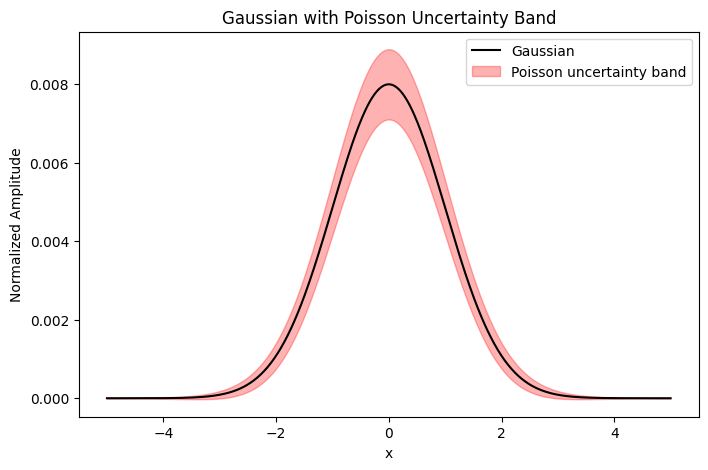

In [70]:
# Parameters for the Gaussian
mu = 0.0      # mean
sigma = 1.0   # standard deviation
x = np.linspace(-5, 5, 500)
gaussian = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
gaussian /= gaussian.sum()  # normalize

# Assume a total number of counts
N_counts = 10000
lambda_vals = gaussian * N_counts  # expected counts at each x

# Poisson uncertainty: sqrt(lambda)
uncertainty = np.sqrt(lambda_vals) / N_counts  # normalize back

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, gaussian, 'k-', label="Gaussian")
plt.fill_between(x, gaussian - uncertainty, gaussian + uncertainty,
                 color='red', alpha=0.3, label="Poisson uncertainty band")

plt.title("Gaussian with Poisson Uncertainty Band")
plt.xlabel("x")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.show()

Text(0.5, 0.04, 'K0 = 0.50 cycles/unit, Sigma = 1, offset = 0.0, orientation = 0.0')

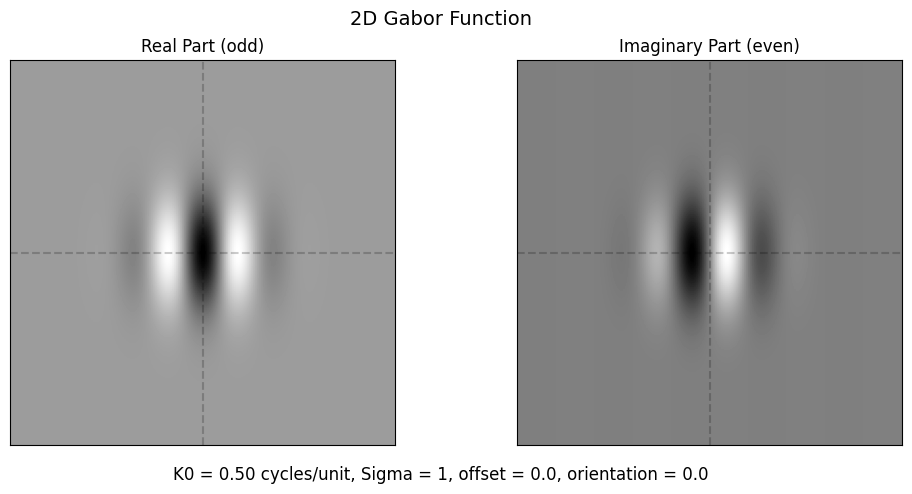

In [71]:
# generate a 2d gaussian function
def gaussian_2d(x, y, sigma):
    return (1/(2*np.pi*sigma**2)) * np.exp(-((x**2 + y**2)/(2*sigma**2)))

# generate a 1d complex exponential
def complex_exponential_1d(x, y, k0, theta, offset):
    x_theta = x*np.cos(theta) + y*np.sin(theta)  
    return np.exp(-1j * (k0 * x_theta + offset))

# generate a 2d gabor function
def gabor_2d(x, y, sigma , k0, theta, offset):
    gauss = gaussian_2d(x, y, sigma)
    complex_exp = complex_exponential_1d(x, y, k0, theta, offset)
    return gauss * complex_exp

# plot the 2d gabor function
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)


sigma = 1

# K0 in cicles per unit
k0 = 2 * np.pi * 0.5  # 0.5 cycles per unit

theta = np.pi * 0  # orientation angle in radians

offset = np.pi * 0  # phase offset in radians

gabor = gabor_2d(X, Y, sigma, k0, theta, offset)

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].imshow(np.real(gabor), extent=(-5, 5, -5, 5), cmap='gray_r')
ax[1].imshow(np.imag(gabor), extent=(-5, 5, -5, 5), cmap='gray_r')
ax[0].set_title('Real Part (odd)')
ax[1].set_title('Imaginary Part (even)')
ax[0].axhline(0, color='black', linestyle='--', alpha=0.2)
ax[0].axvline(0, color='black', linestyle='--', alpha=0.2)
ax[1].axhline(0, color='black', linestyle='--', alpha=0.2)
ax[1].axvline(0, color='black', linestyle='--', alpha=0.2)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])
fig.suptitle('2D Gabor Function', fontsize=14)
fig.text(0.5, 0.04, f"K0 = {k0/(2*np.pi):.2f} cycles/unit, Sigma = {sigma}, offset = {offset}, orientation = {theta}", ha='center', fontsize=12)

(0.0, 100.0)

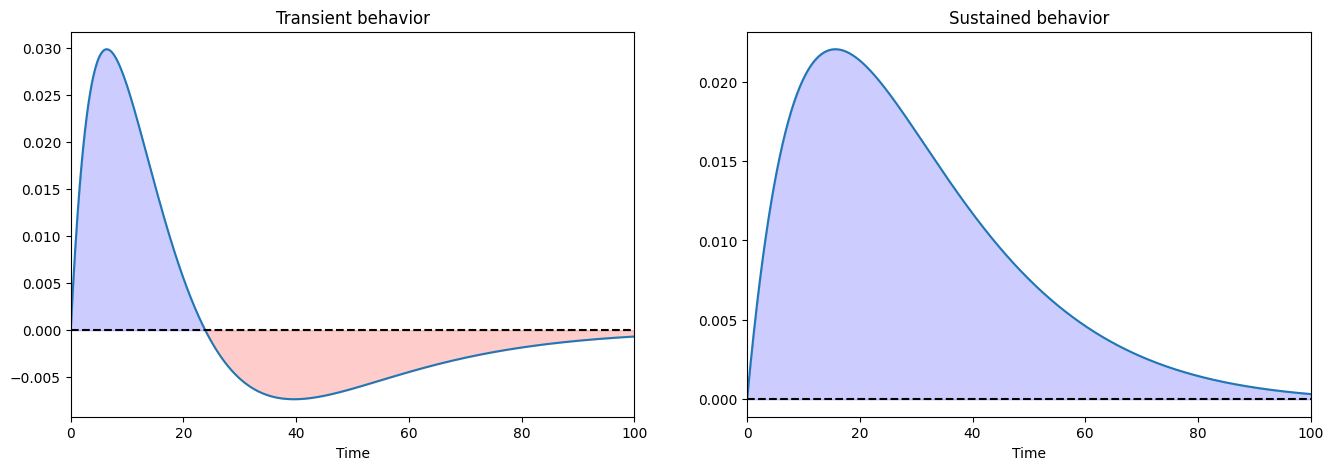

In [220]:
# Transient response parameters
A_tr = 1.0
l_tr= 0.9
tau_1_tr = 8.0
tau_2_tr = 16.0

# Sustained response parameters
A_su = 1.0
l_su= 0.1
tau_1_su = 16
tau_2_su = 32

# Time vector
t = np.linspace(0, 100, 1000)


def double_exponential(t, A, tau_1, tau_2, l):

    # multiply by a step function to ensure causality
    out = A * ((t/tau_1**2)*np.exp(-t/tau_1) - l*(t/tau_2**2)*np.exp(-t/tau_2)) * (t >= 0)

    return out

fig, ax = plt.subplots(1,2, figsize=(16,5))
ax[0].plot(t, double_exponential(t, A_tr, tau_1_tr, tau_2_tr, l_tr))
# fill between curve and x axis
ax[0].fill_between(t, double_exponential(t, A_tr, tau_1_tr, tau_2_tr, l_tr), 0, where=(double_exponential(t, A_tr, tau_1_tr, tau_2_tr, l_tr) >= 0), color='blue', alpha=0.2)
# fill between curve and x axis for negative values
ax[0].fill_between(t, double_exponential(t, A_tr, tau_1_tr, tau_2_tr, l_tr), 0, where=(double_exponential(t, A_tr, tau_1_tr, tau_2_tr, l_tr) < 0), color='red', alpha=0.2)
ax[0].axhline(0, color='black', linestyle='--')
ax[0].set_title("Transient behavior")
ax[0].set_xlabel("Time")
ax[0].set_xlim([0, 100])



ax[1].plot(t, double_exponential(t, A_su, tau_1_su, tau_2_su, l_su))
# fill between curve and x axis
ax[1].fill_between(t, double_exponential(t, A_su, tau_1_su, tau_2_su, l_su), 0, where=(double_exponential(t, A_su, tau_1_su, tau_2_su, l_su) >= 0), color='blue', alpha=0.2)
# fill between curve and x axis for negative values
ax[1].fill_between(t, double_exponential(t, A_su, tau_1_su, tau_2_su, l_su), 0, where=(double_exponential(t, A_su, tau_1_su, tau_2_su, l_su) < 0), color='red', alpha=0.2)
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title("Sustained behavior")
ax[1].set_xlabel("Time")
ax[1].set_xlim([0, 100])



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Define the component functions
def gaussian_1d(x, sigma):
    # Note: Corrected the normalization constant for 1D Gaussian
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(x**2) / (2 * sigma**2))

def sust_env(t, tau):
    return (t / tau) * np.exp(-t / tau)

# Setup coordinate grids
x = np.linspace(-10, 10, 200)
t = np.linspace(0, 50, 200)
X, T = np.meshgrid(x, t)

def update_plot(k0, omega, tau, sigma, offset, alpha):
    
    # Calculate components
    # re_fi_1 = Gaussian * Space_Cos * Env * Time_Cos
    re_fi_1 = gaussian_1d(X, sigma) * np.cos(k0 * X - offset) * sust_env(T, tau) * np.cos(omega * T)
    
    # re_fi_2 = Gaussian * Space_Sin * Env * Time_Sin
    re_fi_2 = gaussian_1d(X, sigma) * np.sin(k0 * X - offset) * sust_env(T, tau) * np.sin(omega * T)
    
    # The sum creates a directional/shifting wave (motion energy)
    re_fi = alpha*re_fi_1 + (1-alpha)*re_fi_2

    fig, ax = plt.subplots(1, 3, figsize=(20, 6))
    
    titles = ['re_fi_1 (Cos/Cos)', 're_fi_2 (Sin/Sin)', 're_fi (Combined)']
    data = [re_fi_1, re_fi_2, re_fi]
    
    for i in range(3):
        im = ax[i].pcolormesh(X, T, data[i], cmap='gray_r', shading='auto')
        ax[i].set_title(titles[i])
        ax[i].set_xlabel("Space")
        ax[i].set_ylabel("Time")
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        # Center line
        ax[i].axvline(0, color='black', linestyle='--', alpha=0.1)

    plt.tight_layout()
    plt.show()

# Create the interactive sliders
interact(update_plot, 
         k0=FloatSlider(min=0, max=5, step=0.1, value=1, description='Spatial Freq (k0)'),
         tau = FloatSlider(min=1, max=20, step=1, value=5, description='Tau (τ)'),
         sigma = FloatSlider(min=0.5, max=10, step=0.5, value=3, description='Sigma (σ)'),
         offset = FloatSlider(min=0, max=2*np.pi, step=0.1, value=0, description='Offset'),
         omega=FloatSlider(min=0.0, max=2, step=0.1, value=1, description='Temporal Freq (ω)'), 
         alpha = FloatSlider(min=0.0, max=1.0, step=0.01, value=0.5, description='Weighting (α)'))


interactive(children=(FloatSlider(value=1.0, description='Spatial Freq (k0)', max=5.0), FloatSlider(value=1.0,…

<function __main__.update_plot(k0, omega, tau, sigma, offset, alpha)>

In [136]:
# Fourier Transform of re_fi
from scipy.fft import fft2, fftshift, ifft2, ifftshift



def update_plot_2(k0, omega, tau, sigma, offset):
    # Calculate components
    # re_fi_1 = Gaussian * Space_Cos * Env * Time_Cos
    re_fi_1 = gaussian_1d(X, sigma) * np.cos(k0 * X - offset) * sust_env(T, tau) * np.cos(omega * T)
    
    # re_fi_2 = Gaussian * Space_Sin * Env * Time_Sin
    re_fi_2 = gaussian_1d(X, sigma) * np.sin(k0 * X - offset) * sust_env(T, tau) * np.sin(omega * T)
    
    # The sum creates a directional/shifting wave (motion energy)
    re_fi = re_fi_1 + re_fi_2

    # Compute 2D FFT and shift zero frequency to center
    F_re_fi = fftshift(fft2(re_fi))

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    ax[0].pcolormesh(X, T, re_fi, cmap='gray_r', shading='auto')
    ax[0].set_title('re_fi (Spatial-Temporal Domain)')
    ax[0].set_xlabel("Space")
    ax[0].set_ylabel("Time")
    ax[0].axvline(0, color='black', linestyle='--', alpha=0.1)
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    ax[1].pcolormesh(np.abs(F_re_fi), cmap='inferno', shading='auto')
    ax[1].set_title('FFT Magnitude (Frequency Domain)')
    ax[1].set_xlabel("Spatial Frequency")
    ax[1].set_ylabel("Temporal Frequency")
    ax[1].axvline(F_re_fi.shape[1]//2, color='red', linestyle='--', alpha=0.5)
    ax[1].axhline(F_re_fi.shape[0]//2, color='red', linestyle='--', alpha=0.5)
    ax[1].set_xticks([])
    ax[1].set_yticks([])

    plt.tight_layout()
    plt.show()

# Create the interactive sliders
interact(update_plot_2, 
         k0=FloatSlider(min=0, max=5, step=0.1, value=1, description='Spatial Freq (k0)'),
         tau = FloatSlider(min=1, max=30, step=1, value=10, description='Tau (τ)'),
         sigma = FloatSlider(min=0.5, max=10, step=0.5, value=3, description='Sigma (σ)'),
         offset = FloatSlider(min=0, max=2*np.pi, step=0.1, value=0, description='Offset'),
         omega=FloatSlider(min=0.0, max=2, step=0.1, value=1, description='Temporal Freq (ω)'))

interactive(children=(FloatSlider(value=1.0, description='Spatial Freq (k0)', max=5.0), FloatSlider(value=1.0,…

<function __main__.update_plot_2(k0, omega, tau, sigma, offset)>